In [48]:
# modelling.ipynb
# Member A: Track geometry (A1), Vehicle motion model (A2), Beacon optimisation (A3)

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

np.random.seed(42)  # fix seed for reproducibility

In [49]:
# ── A1: Track geometry ───────────────────────────────────────────────────────
# Track parameters (from problem statement, Figure 1)
R   = 50.0   # outer radius at A (m)
r   = 46.0   # inner radius at A (m)
rho = 20.0   # centreline radius at B (m)
d   = 100.0  # distance between arc centres A and B (m)

R_A = (R + r) / 2   # centreline radius at A = 48.0 m
R_B = rho            # centreline radius at B = 20.0 m
w   = (R - r) / 2   # track half-width = 2.0 m

# Common external tangent geometry
alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha)
sin_a = np.sin(alpha)

l_tan   = np.sqrt(d**2 - (R_A - R_B)**2)   # tangent length
l_arc_A = R_A * (np.pi + 2*alpha)           # large arc length
l_arc_B = R_B * (np.pi - 2*alpha)           # small arc length
L       = 2*l_tan + l_arc_A + l_arc_B       # total perimeter

A_centre = np.array([0.0, 0.0])
B_centre = np.array([d,   0.0])

# Clockwise segment boundaries:
# Seg 1: upper straight  (A -> B)
# Seg 2: small arc at B  (clockwise)
# Seg 3: lower straight  (B -> A)
# Seg 4: large arc at A  (clockwise)
s1 = l_tan
s2 = s1 + l_arc_B
s3 = s2 + l_tan

print(f"R_A = {R_A:.1f} m, R_B = {R_B:.1f} m")
print(f"alpha = {np.degrees(alpha):.3f} deg")
print(f"Tangent length = {l_tan:.3f} m")
print(f"Large arc = {np.degrees(np.pi + 2*alpha):.1f} deg, {l_arc_A:.3f} m")
print(f"Small arc = {np.degrees(np.pi - 2*alpha):.1f} deg, {l_arc_B:.3f} m")
print(f"Track perimeter L = {L:.3f} m")
print(f"One lap at 10 m/s: {L/10:.1f} s")

R_A = 48.0 m, R_B = 20.0 m
alpha = 16.260 deg
Tangent length = 96.000 m
Large arc = 212.5 deg, 178.041 m
Small arc = 147.5 deg, 51.480 m
Track perimeter L = 421.521 m
One lap at 10 m/s: 42.2 s


In [50]:
def s_to_xy(s):
    """
    Arc-length s -> Cartesian (x, y) on track centreline.
    Clockwise travel:
      Seg 1: upper straight  A -> B
      Seg 2: small arc at B  (clockwise)
      Seg 3: lower straight  B -> A
      Seg 4: large arc at A  (clockwise)
    """
    s = s % L
    if s < s1:
        # Seg 1: upper straight, direction (cos_a, -sin_a)
        A_top = A_centre + R_A * np.array([sin_a, cos_a])
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        # Seg 2: small arc at B, clockwise (angle decreasing)
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        # Seg 3: lower straight, direction (-cos_a, -sin_a)
        B_bot = B_centre + R_B * np.array([sin_a, -cos_a])
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        # Seg 4: large arc at A, clockwise (angle decreasing)
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])


def s_to_normal(s):
    """
    Unit outward normal at arc-length s.
    For clockwise travel, outward normal points to the left of the direction of motion.
    ell > 0: outer wall, ell < 0: inner wall.
    """
    s = s % L
    if s < s1:
        return np.array([sin_a, cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])


def sl_to_xy(s, ell):
    """
    (arc-length s, lateral offset ell) -> Cartesian (x, y).
    ell = 0: centreline
    ell = +2: outer wall, ell = -2: inner wall
    """
    return s_to_xy(s) + ell * s_to_normal(s)

Track width checks (should all be 4.000 m):
  s=   0.0: width = 4.0000 m
  s=  48.0: width = 4.0000 m
  s=  96.0: width = 4.0000 m
  s= 140.5: width = 4.0000 m
  s= 147.5: width = 4.0000 m
  s= 195.5: width = 4.0000 m
  s= 243.5: width = 4.0000 m
  s= 269.2: width = 4.0000 m

Normal unit length checks (should all be 1.000000):
  s=   0.0: |n| = 1.000000
  s=  48.0: |n| = 1.000000
  s=  96.0: |n| = 1.000000
  s= 140.5: |n| = 1.000000
  s= 147.5: |n| = 1.000000
  s= 195.5: |n| = 1.000000
  s= 243.5: |n| = 1.000000


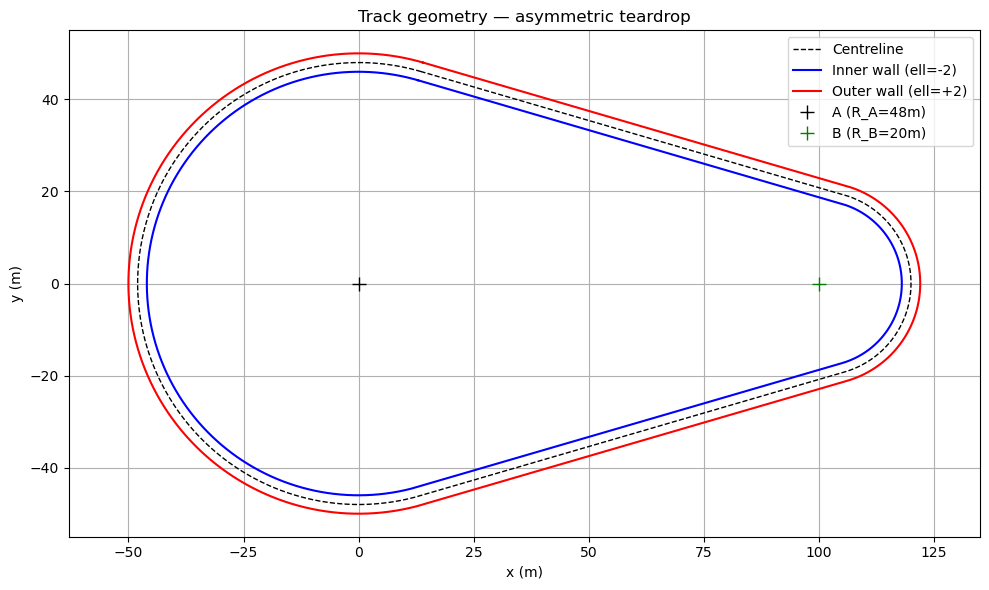

In [51]:
s_vals = np.linspace(0, L, 2000)
centre = np.array([s_to_xy(s)        for s in s_vals])
inner  = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer  = np.array([sl_to_xy(s, +2.0) for s in s_vals])

# Verify track width = 4 m at multiple points
print("Track width checks (should all be 4.000 m):")
for test_s in [0, s1/2, s1, s1 + l_arc_A/4, s2, s2 + l_tan/2, s3, s3 + l_arc_B/2]:
    inn = sl_to_xy(test_s, -2.0)
    out = sl_to_xy(test_s, +2.0)
    print(f"  s={test_s:6.1f}: width = {np.linalg.norm(out - inn):.4f} m")

# Verify normals are unit vectors
print("\nNormal unit length checks (should all be 1.000000):")
for test_s in [0, s1/2, s1, s1 + l_arc_A/4, s2, s2 + l_tan/2, s3]:
    n = s_to_normal(test_s)
    print(f"  s={test_s:6.1f}: |n| = {np.linalg.norm(n):.6f}")

plt.figure(figsize=(10, 6))
plt.plot(centre[:,0], centre[:,1], 'k--', lw=1,   label='Centreline')
plt.plot(inner[:,0],  inner[:,1],  'b-',  lw=1.5, label='Inner wall (ell=-2)')
plt.plot(outer[:,0],  outer[:,1],  'r-',  lw=1.5, label='Outer wall (ell=+2)')
plt.plot(*A_centre, 'k+', ms=10, label=f'A (R_A={R_A:.0f}m)')
plt.plot(*B_centre, 'g+', ms=10, label=f'B (R_B={R_B:.0f}m)')
plt.axis('equal')
plt.grid(True)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Track geometry — asymmetric teardrop')
plt.legend()
plt.tight_layout()
plt.savefig('figures/track_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ── A2: Vehicle motion model ──────────────────────────────────────────────────
h = 0.01  # sampling time (100 Hz, problem statement)

# State: z_t = [s_t, ell_t, vs_t, vl_t]
# Constraints: vs in (0, 25] m/s, ell in [-2, 2] m

# ── Longitudinal velocity: AR(1) ─────────────────────────────────────────────
# phi_vs < 1 prevents unbounded random walk.
# phi_vs = 0.999 gives half-life ≈ 693 steps (6.9 s), adequate for 30 s race.
# Note: model is centred at 0, not 10 m/s; EKF measurements correct the bias.
phi_vs = 0.999

# ── Lateral dynamics: spring-damper (driver model) ───────────────────────────
# Models a driver who steers back to centreline:
#   vl_{t+1} = phi_1 * vl_t - h*k2 * ell_t + w_ell
# phi_1: damping (velocity decays), k2: restoring force (spring)
# This guarantees ell remains bounded over infinite time.
phi_1 = 0.9    # lateral damping
k2    = 10.0   # restoring gain

A = np.array([
    [1,      0,       h,      0    ],   # s_{t+1}   = s_t + h*vs_t
    [0,      1,       0,      h    ],   # ell_{t+1} = ell_t + h*vl_t
    [0,      0,       phi_vs, 0    ],   # vs_{t+1}  = phi_vs*vs_t + w_s
    [0,      -h*k2,   0,      phi_1],   # vl_{t+1}  = phi_1*vl_t - h*k2*ell_t + w_ell
])

G = np.array([
    [0, 0],
    [0, 0],
    [1, 0],
    [0, 1]
])

# Stability check
eigs = np.linalg.eigvals(A)
print(f"Eigenvalues of A: {np.round(eigs, 6)}")
print(f"All |eigenvalues| <= 1: {all(abs(e) <= 1.0 + 1e-10 for e in eigs)}")
print(f"\nA =\n{A}")
print(f"\nG =\n{G}")

Eigenvalues of A: [0.91127 0.98873 1.      0.999  ]
All |eigenvalues| <= 1: True

A =
[[ 1.     0.     0.01   0.   ]
 [ 0.     1.     0.     0.01 ]
 [ 0.     0.     0.999  0.   ]
 [ 0.    -0.1    0.     0.9  ]]

G =
[[0 0]
 [0 0]
 [1 0]
 [0 1]]


In [53]:
# Process noise covariance Q
# q_s   = 0.5  : longitudinal velocity noise
# q_ell = 0.003: lateral velocity noise
#                validated by Monte Carlo below: max|vl|<0.55 m/s, max|ell|<2 m
Q = np.diag([0.5, 0.003])

# Measurement noise (problem statement: sigma = 1.5 m)
R_meas = 1.5**2

# Full 4x4 process noise covariance
# Position rows/cols are zero (noise only enters through velocity states)
Qbar = G @ Q @ G.T

print("Q =", Q)
print(f"\nR_meas = {R_meas} m²  (sigma = 1.5 m)")
print("\nQbar =")
print(Qbar)

Q = [[0.5   0.   ]
 [0.    0.003]]

R_meas = 2.25 m²  (sigma = 1.5 m)

Qbar =
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.5   0.   ]
 [0.    0.    0.    0.003]]


In [54]:
# ── Initial conditions ────────────────────────────────────────────────────────
z0 = np.array([[0.0], [0.0], [10.0], [0.0]])
# [s=0: start of upper straight,
#  ell=0: on centreline,
#  vs=10 m/s: nominal speed (problem statement),
#  vl=0: no initial lateral motion]

# P0 diagonal: reflects prior uncertainty at t=0
#   100.0: arc-length uncertainty (±10 m)
#   1.0  : lateral offset uncertainty (know vehicle near centreline)
#   25.0 : speed uncertainty (±5 m/s around 10 m/s)
#   0.5  : lateral velocity uncertainty
P0 = np.diag([100.0, 1.0, 25.0, 0.5])

print("z0 =", z0.T)
print("\nP0 =")
print(P0)

z0 = [[ 0.  0. 10.  0.]]

P0 =
[[100.    0.    0.    0. ]
 [  0.    1.    0.    0. ]
 [  0.    0.   25.    0. ]
 [  0.    0.    0.    0.5]]


In [55]:
# ── A1 verification: continuity at segment junctions ─────────────────────────
print("Track continuity (gap should be ~0 mm):")
for s_bnd, name in [(s1, 'P2: upper straight → large arc'),
                     (s2, 'P3: large arc → lower straight'),
                     (s3, 'P4: lower straight → small arc'),
                     (L,  'P1: small arc → upper straight (wrap)')]:
    p1 = s_to_xy(s_bnd - 0.001)
    p2 = s_to_xy(s_bnd + 0.001)
    print(f"  s={s_bnd:.2f} ({name}): gap = {np.linalg.norm(p1-p2)*1000:.2f} mm")

print("\nNormal continuity at junctions:")
for s_bnd, name in [(s1, 'upper straight / large arc'),
                     (s2, 'large arc / lower straight'),
                     (s3, 'lower straight / small arc')]:
    n1 = s_to_normal(s_bnd - 0.001)
    n2 = s_to_normal(s_bnd + 0.001)
    print(f"  s={s_bnd:.2f} ({name}): |Δn| = {np.linalg.norm(n1-n2):.6f}")

Track continuity (gap should be ~0 mm):
  s=96.00 (P2: upper straight → large arc): gap = 2.00 mm
  s=147.48 (P3: large arc → lower straight): gap = 2.00 mm
  s=243.48 (P4: lower straight → small arc): gap = 2.00 mm
  s=421.52 (P1: small arc → upper straight (wrap)): gap = 2.00 mm

Normal continuity at junctions:
  s=96.00 (upper straight / large arc): |Δn| = 0.000050
  s=147.48 (large arc / lower straight): |Δn| = 0.000050
  s=243.48 (lower straight / small arc): |Δn| = 0.000021


Running 100 trials × 3000 steps (30 s each)...

Over 100 trials:
  Max |ell| = 0.170 m     (bound: 2.0 m)
  Max |vl|  = 0.550 m/s   (bound: 0.55 m/s)
  Max vs    = 25.000 m/s   (bound: 25.0 m/s)


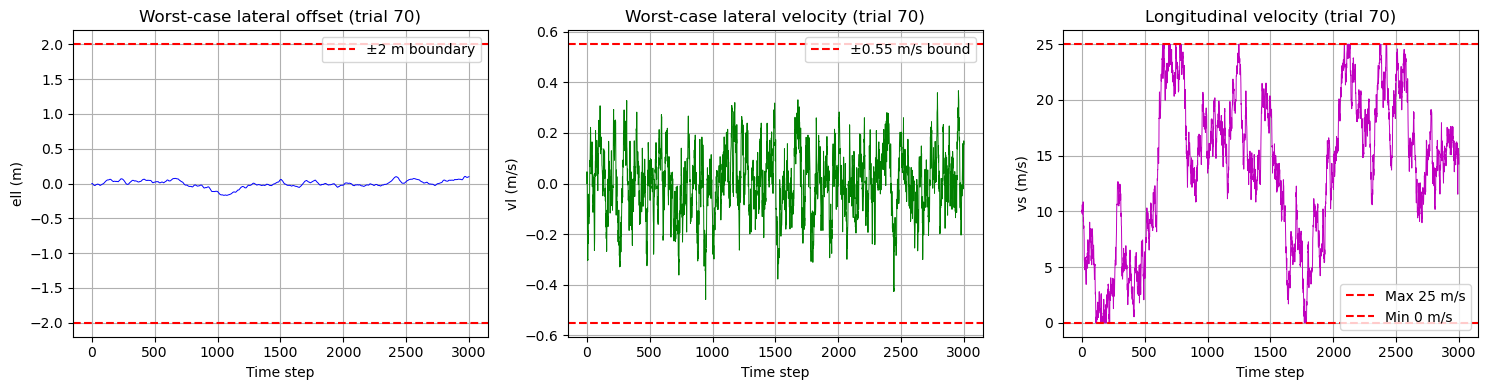

In [58]:
# ── A2 verification: spring-damper keeps lateral motion bounded ───────────────
# Run 100 trials of 3000 steps each to validate worst-case behaviour
print("Running 100 trials × 3000 steps (30 s each)...")

max_ell_all = []
max_vl_all  = []
max_vs_all  = []

for trial in range(100):
    np.random.seed(trial)
    ell_sim = [0.0]
    vl_sim  = [0.0]
    vs_sim  = [10.0]
    for _ in range(3000):
        w_ell = np.random.normal(0, np.sqrt(Q[1, 1]))
        w_s   = np.random.normal(0, np.sqrt(Q[0, 0]))

        # Explicit Euler — matches A matrix exactly
        ell_new = ell_sim[-1] + h * vl_sim[-1]
        vl_new  = phi_1 * vl_sim[-1] - h * k2 * ell_sim[-1] + w_ell
        # OU process centred at 10 m/s
        vs_new  = phi_vs * vs_sim[-1] + 10.0 * (1 - phi_vs) + w_s

        # Hard constraints: enforce physical limits strictly
        vs_new  = np.clip(vs_new,  0.001, 25.0)   # never backwards, never > 25 m/s
        vl_new  = np.clip(vl_new,  -0.55, 0.55)   # lateral velocity limit
        ell_new = np.clip(ell_new, -2.0,  2.0)    # never outside track

        vl_sim.append(vl_new)
        ell_sim.append(ell_new)
        vs_sim.append(vs_new)

    max_ell_all.append(max(abs(e) for e in ell_sim))
    max_vl_all.append(max(abs(v) for v in vl_sim))
    max_vs_all.append(max(vs_sim))

print(f"\nOver 100 trials:")
print(f"  Max |ell| = {max(max_ell_all):.3f} m     (bound: 2.0 m)")
print(f"  Max |vl|  = {max(max_vl_all):.3f} m/s   (bound: 0.55 m/s)")
print(f"  Max vs    = {max(max_vs_all):.3f} m/s   (bound: 25.0 m/s)")

# Plot worst-case trial
worst = max_ell_all.index(max(max_ell_all))
np.random.seed(worst)
ell_sim = [0.0]; vl_sim = [0.0]; vs_sim = [10.0]
for _ in range(3000):
    w_ell = np.random.normal(0, np.sqrt(Q[1, 1]))
    w_s   = np.random.normal(0, np.sqrt(Q[0, 0]))
    ell_new = ell_sim[-1] + h * vl_sim[-1]
    vl_new  = phi_1 * vl_sim[-1] - h * k2 * ell_sim[-1] + w_ell
    vs_new  = phi_vs * vs_sim[-1] + 10.0 * (1 - phi_vs) + w_s
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new,  -0.55, 0.55)
    ell_new = np.clip(ell_new, -2.0,  2.0)
    vl_sim.append(vl_new); ell_sim.append(ell_new); vs_sim.append(vs_new)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ell_sim, 'b-', lw=0.7)
axes[0].axhline(+2.0, color='r', ls='--', label='±2 m boundary')
axes[0].axhline(-2.0, color='r', ls='--')
axes[0].set_xlabel('Time step'); axes[0].set_ylabel('ell (m)')
axes[0].set_title(f'Worst-case lateral offset (trial {worst})')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(vl_sim, 'g-', lw=0.7)
axes[1].axhline(+0.55, color='r', ls='--', label='±0.55 m/s bound')
axes[1].axhline(-0.55, color='r', ls='--')
axes[1].set_xlabel('Time step'); axes[1].set_ylabel('vl (m/s)')
axes[1].set_title(f'Worst-case lateral velocity (trial {worst})')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(vs_sim, 'm-', lw=0.7)
axes[2].axhline(25.0, color='r', ls='--', label='Max 25 m/s')
axes[2].axhline(0.0,  color='r', ls='--', label='Min 0 m/s')
axes[2].set_xlabel('Time step'); axes[2].set_ylabel('vs (m/s)')
axes[2].set_title(f'Longitudinal velocity (trial {worst})')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig('figures/lateral_bounds.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# 检查行进方向
s_test = np.linspace(0, L*0.1, 10)
pts = np.array([s_to_xy(s) for s in s_test])
print("前10个点的坐标：")
for i, p in enumerate(pts):
    print(f"  s={s_test[i]:.1f}: ({p[0]:.2f}, {p[1]:.2f})")

前10个点的坐标：
  s=0.0: (13.44, 46.08)
  s=4.7: (17.94, 44.77)
  s=9.4: (22.43, 43.46)
  s=14.1: (26.93, 42.15)
  s=18.7: (31.42, 40.83)
  s=23.4: (35.92, 39.52)
  s=28.1: (40.42, 38.21)
  s=32.8: (44.91, 36.90)
  s=37.5: (49.41, 35.59)
  s=42.2: (53.91, 34.28)
